In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


The case study is from an open source dataset from Kaggle. 

Link to the Kaggle project site:

https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling (Links to an external site.)Links to an external site.

**The NN model will be built to identify if customers are leaving the bank or not and their dependencies on one another**

In [0]:
#Import the required libraries
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

**1. Read the dataset**

In [0]:
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/bank.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
print('DataTypes:')
print(df.dtypes)
print("")

print('Info:')
print(df.info())
print("")

print('columns:')
print(df.columns)
print("")

print('shape:')
print(df.shape)
print("")

print('IsNull?:')
print(df.isnull().values.any())
print('no of nulls: ', df.isnull().sum())
print("")

print('IsNA?:')
print(df.isna().values.any())
print('no of NAs: ', df.isna().sum())
print("")

print("Number of NULL values in each column:")
print(df.isnull().apply(sum))
print(df.isna().apply(sum))

print('Check for zeroes in the data')
print(('No of zeros', ((df==0).sum().to_frame().T)))
print("")
      
print("Median:")
print(df.median())
print("")


print('mean:')
print(df.mean())
print("")

print('std:')
print(df.std())
print("")

print('Data basic statistics:')
df.describe().transpose()

DataTypes:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             10000 non-null int64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


**About the data:**

There are 14 columns and the column **"Exited"** is the classification output (binary 1 or 0), **the target variable**, indicating if the custimer exited the bank or not. It is an integer.

All of the columns have 10000 entries

Geography is an object
Balance and EstimatedSalary are float

***None of the features have missing data, or invalid data***

 



**The independent variables (faeatures) are**:

Credit Score: reliability of the customer

Geography: where is the customer from

Gender: Male or Female

Age

Tenure: number of years of customer history in the company

Balance: the money in the bank account

Number of products of the customer in the bank

Credit Card: if the customer has or not the CC

Active: if the customer is active or not

Estimated Salary: estimation of salary based on the entries

**Plot the Data**

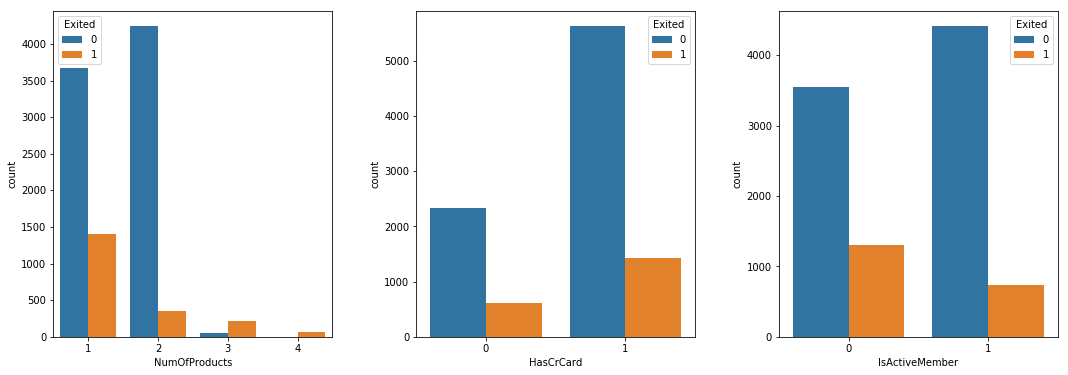

In [6]:
#Check how many customers have exited along wrt some of these features  
#to understand the number of them quit based on the category of the feature
_, ax = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)
sns.countplot(x = "NumOfProducts", hue="Exited", data = df, ax= ax[0])
sns.countplot(x = "HasCrCard", hue="Exited", data = df, ax = ax[1])
sns.countplot(x = "IsActiveMember", hue="Exited", data = df, ax = ax[2])

Customers with more number of products have exited more. Example, number of customers who owned 3 products exited more than the number of existing ones and almost all the ones with 4 products have exited

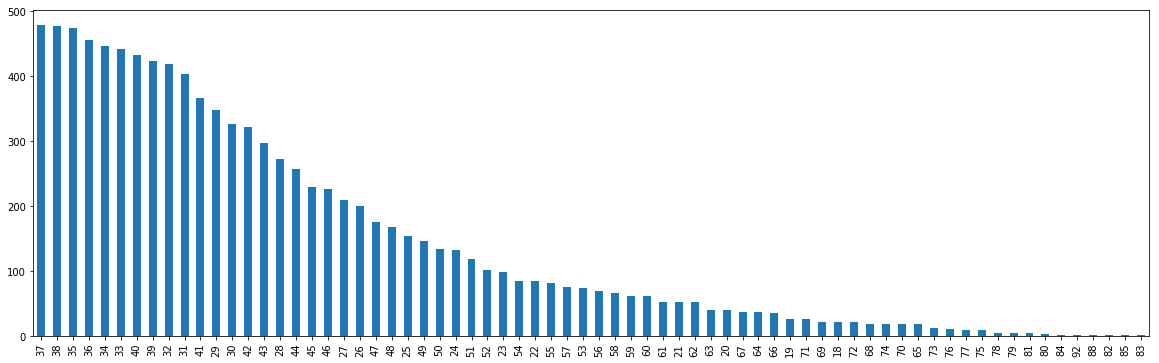

In [7]:
#Check the age distriution of the customers
df["Age"].value_counts().plot.bar(figsize=(20,6))

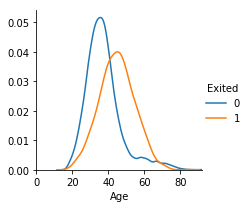

In [8]:
facet = sns.FacetGrid(df, hue="Exited")
facet.map(sns.kdeplot,"Age")
facet.set(xlim=(0, df["Age"].max()))
facet.add_legend()

plt.show()

Probability of middle age to senior age (40-70yrs) customers leveing the bank is higher than the probability of young age customers leaving.

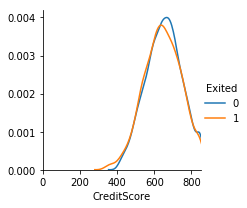

In [9]:
facet = sns.FacetGrid(df, hue="Exited")
facet.map(sns.kdeplot,"CreditScore")
facet.set(xlim=(0, df["CreditScore"].max()))
facet.add_legend()

plt.show()

Looks like creditscore has no impact on exiting the bank

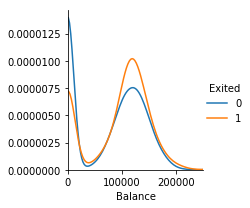

In [10]:
facet = sns.FacetGrid(df, hue="Exited")
facet.map(sns.kdeplot,"Balance")
facet.set(xlim=(0, df["Balance"].max()))
facet.add_legend()

plt.show()

**Check the Correlation**

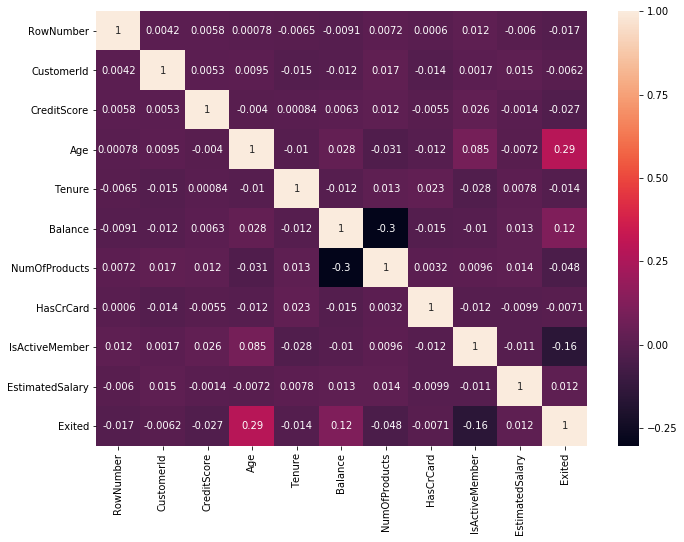

In [11]:
plt.subplots(figsize=(11,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

The variables are not highly correlated at all. We could keep all the features since one indepenent variable doens't influence the other independent variable


**2. Drop the columns which are unique for all users like IDs (5 points)**

Also remove the output variable from the input features X


*Data types and usefulness of columns:*

The RowNumber, CustomerId are unique to each customer and will not be useful to identify if they will leave or not. Hence we could drop these columns.

On an ethical basis we shouldn't be considering the surname to be a related variable and hence drop the same. It is simply a family name of the person

**3. Distinguish the feature and target set (5 points)**

In [0]:
X = df.drop(["RowNumber", "CustomerId", "Surname", "Exited"],axis=1)
Y = df["Exited"]

In [13]:
#Features
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [14]:
#Target
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [15]:
X.shape

(10000, 10)

Now we have 10 input features to analyze

In [16]:
Y.shape

(10000,)

In [17]:
#Encode categorical data into numerical data. (Gender and Geography)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Gender will have 0,1 instead of Male and Female
labelencoder_gender = LabelEncoder()
X["Gender"] = labelencoder_gender.fit_transform(X["Gender"])
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,0,42,2,0.00,1,1,1,101348.88
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58
2,502,France,0,42,8,159660.80,3,1,0,113931.57
3,699,France,0,39,1,0.00,2,0,0,93826.63
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10


In [18]:
# Geography will have 0,1,2 instead of France, Spain and Gemany 
labelencoder_geo = LabelEncoder()
X["Geography"] = labelencoder_geo.fit_transform(X["Geography"])
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [19]:
#For the Geography, create dummy variables, creating one column for each country
from keras.utils import to_categorical
encoded = pd.DataFrame(to_categorical(X.iloc[:, 1]))

X = pd.concat([encoded, X], axis = 1)
X.head()

Using TensorFlow backend.


,0,1,2,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,1.0,0.0,0.0,619,0,0,42,2,0.00,1,1,1,101348.88
1,0.0,0.0,1.0,608,2,0,41,1,83807.86,1,0,1,112542.58
2,1.0,0.0,0.0,502,0,0,42,8,159660.80,3,1,0,113931.57
3,1.0,0.0,0.0,699,0,0,39,1,0.00,2,0,0,93826.63
4,0.0,0.0,1.0,850,2,0,43,2,125510.82,1,1,1,79084.10


In [20]:
X = X.drop(['Geography', 0], axis = 1)
X.head()

,1,2,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,0.0,0.0,619,0,42,2,0.00,1,1,1,101348.88
1,0.0,1.0,608,0,41,1,83807.86,1,0,1,112542.58
2,0.0,0.0,502,0,42,8,159660.80,3,1,0,113931.57
3,0.0,0.0,699,0,39,1,0.00,2,0,0,93826.63
4,0.0,1.0,850,0,43,2,125510.82,1,1,1,79084.10


In [21]:
X.head()

,1,2,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,0.0,0.0,619,0,42,2,0.00,1,1,1,101348.88
1,0.0,1.0,608,0,41,1,83807.86,1,0,1,112542.58
2,0.0,0.0,502,0,42,8,159660.80,3,1,0,113931.57
3,0.0,0.0,699,0,39,1,0.00,2,0,0,93826.63
4,0.0,1.0,850,0,43,2,125510.82,1,1,1,79084.10


In [22]:
X.shape

(10000, 11)

Now we have 11 input features from which we need to identify the customers who are more probable to exit

**4. Divide the data set into Train and test sets**

In [0]:
# Split the data into the Training and Testing set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 99)

In [24]:
X_test.shape

(3000, 11)

In [25]:
X_train.shape

(7000, 11)

**5. Normalize the train and test data (5 points)**

In [0]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**6. Initialize & build the model (10 points)**

In [27]:
import keras
import sys

from keras.models import Sequential 
from keras.layers import Dense 

#Initialising the model for ANN
model = Sequential()

#initialize weights randomly 
#input_dimension is the same as number of nodes
#output_dimension is the number of nodes of the next hidden layer, usually hidden layer's number of node can be half of input dimension
model.add(Dense(init='random_uniform', activation = 'relu', input_dim = 11, output_dim = 6))

#Add a hidden layer
#no need of input_dimension to be mentioned here
model.add(Dense(init='random_uniform', activation = 'relu', output_dim = 6))

#output layer
#output_dimension is 1 since it is binary output
#activation can be ReLU only in dense laye . Output can use 'sigmoid'
#If more than two categories, use activation = 'softmax'
model.add(Dense(output_dim = 1, init='random_uniform', activation = 'sigmoid'))


W0901 15:12:32.918856 139638407489408 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:66: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:13: UserWarning: Update your `Dense` call to the Keras 2 API: `Dense(activation="relu", input_dim=11, units=6, kernel_initializer="random_uniform")`
  del sys.path[0]
W0901 15:12:32.940886 139638407489408 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:541: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0901 15:12:32.943813 139638407489408 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4432: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

/usr/local/lib/python3.6/dist-packages/ipykernel_launche

In [28]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 6)                 72        
_________________________________________________________________
dense_2 (Dense)              (None, 6)                 42        
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 7         
Total params: 121
Trainable params: 121
Non-trainable params: 0
_________________________________________________________________


**7.Optimize the model (Optional)**

In [29]:
#compile
#use adam optimizer algorithm to find the optimal set of weights in ANN
#Here 'binary_crossentropy' loss function is enough since it is binary output. "categorical_crossentropy" for loss function only if more than two categories. 
#Use accuracy criteria to calculate the performance of the model
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

W0901 15:12:50.283842 139638407489408 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/optimizers.py:793: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0901 15:12:50.316284 139638407489408 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3657: The name tf.log is deprecated. Please use tf.math.log instead.

W0901 15:12:50.323861 139638407489408 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/nn_impl.py:180: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


batch_size: How often we want to back-propogate the error values so that individual node weights can be adjusted.

nb_epochs: The number of times we want to run the entire test data over again to tune the weights. This is like the fuel of the algorithm.

In [38]:
#fit with train data
#Use Adam as optimization algorithms, which is an efficient variant of Gradient Descent algorithm
model.fit(X_train, y_train, batch_size = 10, nb_epoch = 100,validation_data=(X_test, y_test))

Train on 7000 samples, validate on 3000 samples
Epoch 1/100
1370/7000 [====>.........................] - ETA: 0s - loss: 0.3970 - acc: 0.8343

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


7000/7000 [==============================] - 1s 134us/step - loss: 0.3967 - acc: 0.8389 - val_loss: 0.4054 - val_acc: 0.8340
Epoch 2/100
7000/7000 [==============================] - 1s 133us/step - loss: 0.3972 - acc: 0.8364 - val_loss: 0.4049 - val_acc: 0.8310
Epoch 3/100
7000/7000 [==============================] - 1s 135us/step - loss: 0.3966 - acc: 0.8386 - val_loss: 0.4048 - val_acc: 0.8313
Epoch 4/100
7000/7000 [==============================] - 1s 134us/step - loss: 0.3966 - acc: 0.8380 - val_loss: 0.4050 - val_acc: 0.8337
Epoch 5/100
7000/7000 [==============================] - 1s 138us/step - loss: 0.3971 - acc: 0.8374 - val_loss: 0.4050 - val_acc: 0.8307
Epoch 6/100
7000/7000 [==============================] - 1s 137us/step - loss: 0.3967 - acc: 0.8356 - val_loss: 0.4046 - val_acc: 0.8330
Epoch 7/100
7000/7000 [==============================] - 1s 139us/step - loss: 0.3969 - acc: 0.8380 - val_loss: 0.4050 - val_acc: 0.8323
Epoch 8/100
7000/7000 [==============================

**8. Predict the results using 0.5 as a threshold (Optional)**

In [0]:
#Predict the test data
#if y_pred is larger than 0.5 it returns true else false
yPred = model.predict(X_test)
yPred = (yPred > 0.5)

**9. Print the Accuracy score and confusion matrix (5 points)**

In [40]:
#Print Confusion Matrix
from sklearn import metrics
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, yPred)

array([[2286,   82],
       [ 414,  218]])

In [41]:
accuracy = (2289+203)/3000
accuracy

0.8306666666666667

In [42]:
metrics.accuracy_score(y_test,yPred)

0.8346666666666667